# Mashup dataset 2025

In [1]:
import glob
import pandas as pd
import xarray as xr
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np

import mashup2025_pps_nwp_awsprom_lev2 as mupy

In [2]:
stations = { # "name": (lat,lon)
    "EGP": (75.62, -35.97),
    "KAN_U": (67.0, -47.03),
    "KPC_U": (79.83, -25.17),
    "UPE_U": (72.89, -53.58),
    "SCO_U": (72.39, -27.23),
    "QAS_U": (61.18, -46.82),
}

dt = 1800 # s
dx = 10 # km

## Test on one segment: 24/05/25 22:10

In [3]:
cma_file = "/dmidata/users/zoerem/data/input_PPS_2025_files/S_NWC_CMA_metopb_00000_20250524T2210030Z_20250524T2213030Z.nc"

# df = mupy.process_segment_cloud_mask(cma_file, stations, dt, dx)
# df.head()

In [4]:
df_cc = xr.open_dataset(cma_file, engine="netcdf4", decode_timedelta=True)
lat_grid = df_cc['lat']
lon_grid = df_cc['lon']
cma = df_cc['cma']

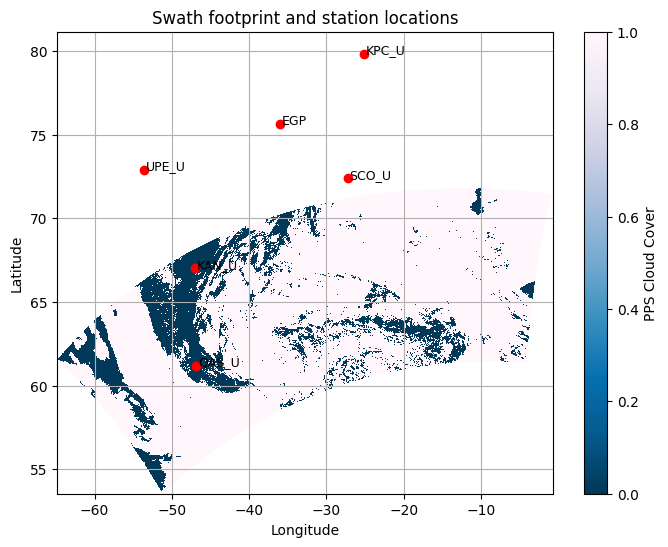

In [5]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(lon_grid, lat_grid, cma, cmap="PuBu_r") #, shading="auto")
plt.colorbar(label="PPS Cloud Cover")
for name, (lat, lon) in stations.items():
    plt.plot(lon, lat, "ro")
    plt.text(lon + 0.2, lat, name, fontsize=9)
plt.title("Swath footprint and station locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

## Loop on all CMA segments

In [1]:
# cma_dir = "/dmidata/users/zoerem/data/input_PPS_2025_files/S_NWC_CMA_metopb_00000_*.nc"

# cma_files = sorted(glob.glob(cma_dir))

# # Final DataFrame
# all_results = []

# print(f"Found {len(cma_files)} CMA files to process")

# for cma_file in tqdm(cma_files, desc="Processing PPS segments"):
#     try:
#         df = mupy.process_segment_cloud_mask(cma_file, stations, dt, dx)
#         if not df.empty:
#             all_results.append(df)
#     except Exception as e:
#         print(f"Error processing {cma_file}: {e}")
#         continue

In [2]:
# # Concatenates all DataFrames
# if all_results:
#     final_df = pd.concat(all_results, ignore_index=True)
#     csv_path = "/dmidata/users/zoerem/data/mashup_2025.csv"
#     final_df.to_csv(csv_path, index=False)
#     print(f"Mashup saved: {csv_path} ({len(final_df)} rows)")
# else:
#     print("No valid data found across all segments.")